# Interpreting Decision Trees using Feature Importance & SHAP


Github: https://github.com/rishivarma1203/Machine-Learning

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

sns.set_style("whitegrid")

### Load the dataset

In [ ]:
df = sns.load_dataset("titanic")

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


### Select Features

In [ ]:
features = ["pclass", "sex", "age", "fare"]

data = df[features + ["survived"]].dropna()

data["sex"] = data["sex"].map({"male":0, "female":1})

data.head()

,pclass,sex,age,fare,survived
0,3,0,22.0,7.2500,0
1,1,1,38.0,71.2833,1
2,3,1,26.0,7.9250,1
3,1,1,35.0,53.1000,1
4,3,0,35.0,8.0500,0


### Dataset Distribution plot

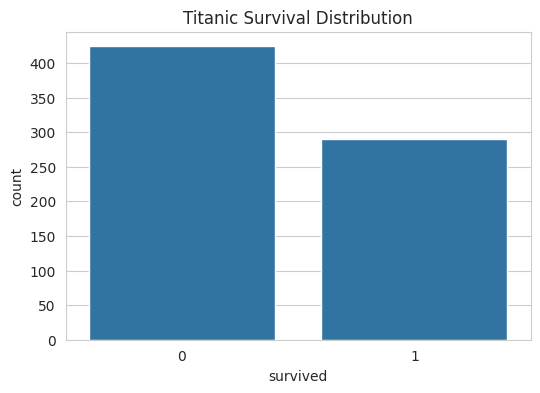

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(data=data, x="survived")

plt.title("Titanic Survival Distribution")

plt.savefig("titanic_data_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

### Preparing data

In [ ]:
X = data[features]
y = data["survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

### Train Decision tree

In [ ]:
model = DecisionTreeClassifier(max_depth=3, random_state=42)

model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

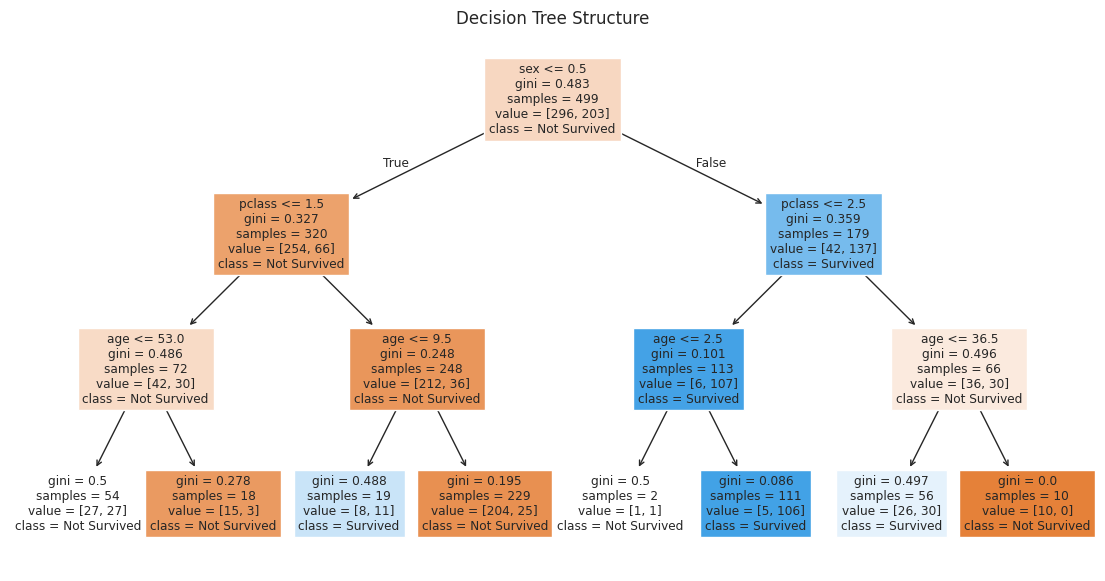

In [ ]:
plt.figure(figsize=(14,7))

plot_tree(
    model,
    feature_names=features,
    class_names=["Not Survived","Survived"],
    filled=True
)

plt.title("Decision Tree Structure")

plt.savefig("decision_tree_structure.png", dpi=300, bbox_inches="tight")

plt.show()

### Feature Importance plot

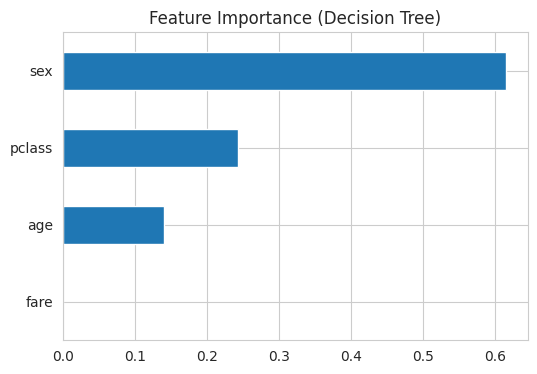

In [ ]:
importances = model.feature_importances_

feat_imp = pd.Series(importances, index=features).sort_values()

plt.figure(figsize=(6,4))

feat_imp.plot(kind="barh")

plt.title("Feature Importance (Decision Tree)")

plt.savefig("feature_importance.png", dpi=300, bbox_inches="tight")

plt.show()

### SHAP

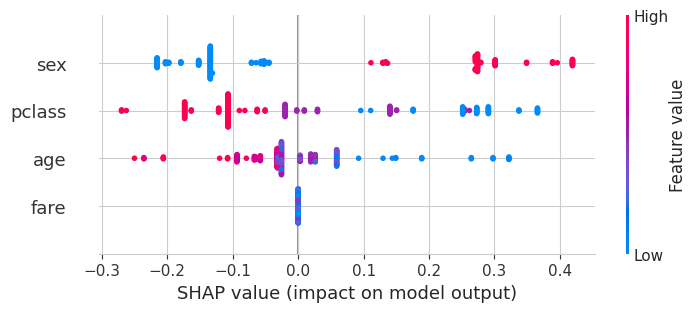

In [ ]:
explainer = shap.Explainer(model, X_train)

shap_values = explainer(X_test)
plt.figure()

shap.plots.beeswarm(shap_values[:, :, 1], show=False)

plt.savefig("shap_summary_plot.png", dpi=300, bbox_inches="tight")

plt.show()

### SHAP Waterfall plot

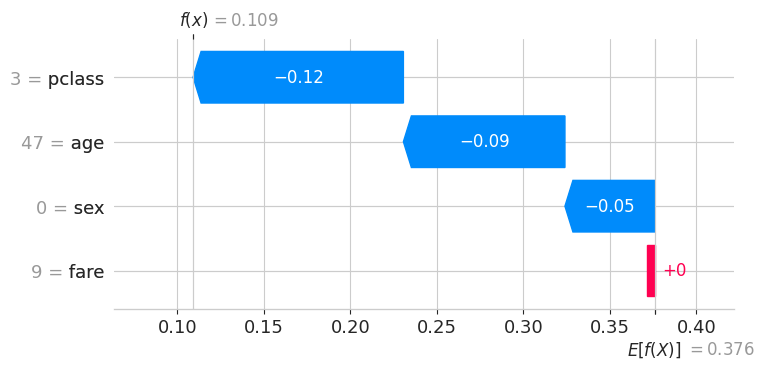

In [ ]:
# Select one passenger example
sample_index = 0

plt.figure()

shap.plots.waterfall(shap_values[sample_index, :, 1], show=False)

plt.savefig("shap_waterfall_example.png", dpi=300, bbox_inches="tight")

plt.show()

### SHAP Bar plot

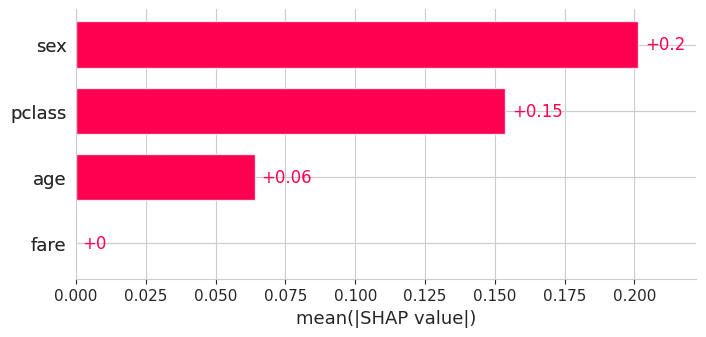

In [ ]:
plt.figure()

shap.plots.bar(shap_values[:, :, 1], show=False)

plt.savefig("shap_bar_plot.png", dpi=300, bbox_inches="tight")

plt.show()

### Model Performance

In [ ]:
pred = model.predict(X_test)

acc = accuracy_score(y_test, pred)
prec = precision_score(y_test, pred)
rec = recall_score(y_test, pred)
f1 = f1_score(y_test, pred)

results_df = pd.DataFrame({
    "Metric":["Accuracy","Precision","Recall","F1 Score"],
    "Value":[acc,prec,rec,f1]
})

results_df

,Metric,Value
0,Accuracy,0.776744
1,Precision,0.719101
2,Recall,0.735632
3,F1 Score,0.727273
